# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


# Path

In [2]:
project_root = Path().resolve()
data_path = project_root / "data"
figure_path = project_root / "figures"
print(project_root)
print(data_path)
print(data_path.exists())

C:\Users\joris\OneDrive\Desktop\econometrie\QFAT\Assignment
C:\Users\joris\OneDrive\Desktop\econometrie\QFAT\Assignment\data
True


# Data

In [12]:
# prepare data table
industry_returns = pd.read_csv(data_path / "Industry.csv")
industry_returns = industry_returns.drop(columns=['Rf', 'MktRf'])
print(industry_returns.columns)

Index(['mdate', 'Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths',
       'Hlth', 'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos',
       'Carry', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq',
       'Paper', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other'],
      dtype='object')


# Data Formatting

In [13]:
industry_returns['mdate'] = pd.to_datetime(industry_returns['mdate'].astype(str), format="%Y%m")
industry_returns = industry_returns.set_index('mdate')
industry_returns = industry_returns.sort_index()

industry_returns = industry_returns.replace("%", "", regex=True).astype(float) / 100
industry_returns.head()

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
mdate,,,,,,,,,,,,,,,,,,,,,
1926-07-01,0.0053,-0.0519,0.0129,0.0230,0.1097,-0.0050,0.0808,0.0164,0.0792,0.0068,...,0.0083,0.0922,0.0206,0.0766,0.0191,-0.2379,-0.0294,0.0183,0.0016,0.0520
1926-08-01,0.0271,0.2703,0.0653,0.0054,0.1001,-0.0358,-0.0251,0.0451,0.0541,0.0749,...,0.0217,0.0202,0.0440,-0.0237,0.0487,0.0539,-0.0056,-0.0009,0.0438,0.0676
1926-09-01,0.0129,0.0402,0.0122,0.0592,-0.0099,0.0071,-0.0051,0.0061,0.0537,0.0240,...,0.0241,0.0225,0.0018,-0.0555,0.0006,-0.0787,0.0017,-0.0058,-0.0136,-0.0386
1926-10-01,-0.0313,-0.0331,0.0107,-0.0441,0.0947,-0.0466,0.0012,-0.0073,-0.0479,0.0007,...,-0.0011,-0.0200,-0.0108,-0.0503,-0.0265,-0.1538,-0.0534,-0.0413,-0.0509,-0.0849
1926-11-01,0.0628,0.0729,0.0441,0.0260,-0.0580,-0.0051,0.0187,0.0553,0.0534,0.0348,...,0.0163,0.0377,0.0364,0.0381,0.0159,0.0467,0.0404,0.0432,0.0229,0.0400


# Rank per month

In [23]:
industry_avg_returns = industry_returns.shift(1).rolling(window=12).mean().dropna()
industry_avg_returns.to_csv(data_path / "industry_avg_return.csv")

industry_ranks = industry_avg_returns.rank(axis=1, method="min", ascending=True).astype(int)
industry_ranks.to_csv(data_path / "industry_ranks.csv")
head = industry_ranks.head()
print(head)

            Food  Beer  Smoke  Games  Books  Hshld  Clths  Hlth  Chems  Txtls  \
mdate                                                                           
1927-07-01    14    30     24      3     29      7     17    20     28     25   
1927-08-01    15    30     27      3     26      8     10    22     29     28   
1927-09-01    14    17     26      4     24     10     13    18     30     22   
1927-10-01    13    17     27      3     29      8     12    20     30     19   
1927-11-01    13    18     24      3     23     10     20    27     30     15   

            ...  Telcm  Servs  BusEq  Paper  Trans  Whlsl  Rtail  Meals  Fin  \
mdate       ...                                                                
1927-07-01  ...     15     26     23      4     18      1      6     16   13   
1927-08-01  ...     13     19     24      5     16      1      9     14   17   
1927-09-01  ...      9     27     25      5      8      1     20     16   15   
1927-10-01  ...     10     22   

# Average Rank per month

In [15]:
industry_avg_ranks = industry_ranks.mean(axis=0)
industry_avg_ranks.to_csv(data_path / "industry_avg_ranks.csv")
show = industry_avg_ranks.sort_values()
print(show)

Telcm    14.087824
Other    14.215569
Clths    14.540918
Util     14.767465
Whlsl    14.773453
Steel    14.888224
Cnstr    14.908184
Hshld    14.942116
Mines    14.957086
Books    14.974052
Trans    14.999002
Food     15.182635
Txtls    15.238523
Rtail    15.381238
Chems    15.488024
Paper    15.507984
Hlth     15.656687
FabPr    15.760479
Fin      15.802395
Oil      15.910180
Meals    15.951098
Coal     16.004990
Autos    16.012974
BusEq    16.092814
Smoke    16.216567
Games    16.247505
Beer     16.386228
Servs    16.410180
Carry    16.517964
ElcEq    17.167665
dtype: float64


# Long vs Short

In [16]:
industry_long_short = (industry_ranks > len(industry_ranks.columns) // 2)    #monthly winners vs losers
industry_avg_long_short = industry_long_short.mean(axis=0)  #average winner frequency per industry

worst_industries = industry_avg_long_short.sort_values().index.to_list()[0:int(len(industry_avg_long_short) / 2)]    #15 worst industries in the losers portofolio
best_industries = industry_avg_long_short.sort_values(ascending=False).index.to_list()[0:int(len(industry_avg_long_short) / 2)]  #15 best industries in the winners portofolio
print("Best industries:", best_industries)
print("Worst industries:", worst_industries)

Best industries: ['ElcEq', 'Carry', 'Beer', 'FabPr', 'Servs', 'Games', 'BusEq', 'Coal', 'Smoke', 'Meals', 'Oil', 'Fin', 'Chems', 'Txtls', 'Autos']
Worst industries: ['Other', 'Telcm', 'Cnstr', 'Whlsl', 'Clths', 'Steel', 'Books', 'Food', 'Hshld', 'Trans', 'Rtail', 'Mines', 'Paper', 'Util', 'Hlth']


# Average 12 month return for the Industries

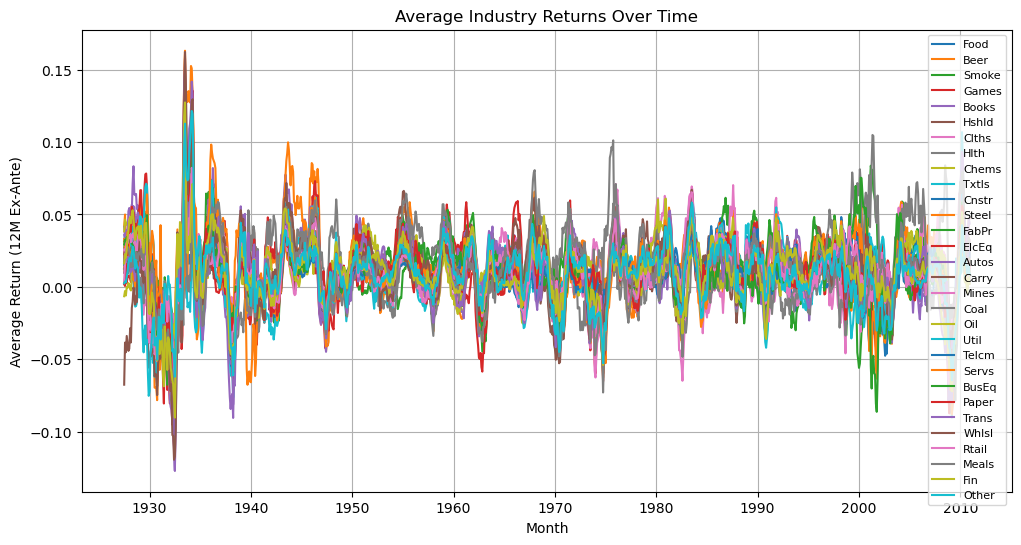

In [17]:
####################################################################################
# General

plt.figure(figsize=(12, 6))
for col in industry_avg_returns:
    plt.plot(industry_avg_returns.index, industry_avg_returns[col], label=col)

plt.xlabel("Month")
plt.ylabel("Average Return (12M Ex-Ante)")
plt.title("Average Industry Returns Over Time")
plt.legend(loc="best", fontsize=8)
plt.grid(True)

plt.savefig(figure_path / "avg_ind_return.png")

####################################################################################

# Q 1.1a Which industry has the lowest average rank and which has the highest?


In [18]:

industry_avg_ranks = industry_ranks.mean(axis=0)
industry_avg_ranks.to_csv(data_path / "industry_avg_ranks.csv")
show = industry_avg_ranks.sort_values()
worst_avg_rank_industries = industry_avg_ranks.sort_values().index.to_list()[0:int(len(industry_avg_ranks) / 2)]     #Find the lowest average rank industries
best_avg_rank_industries = industry_avg_ranks.sort_values(ascending=False).index.to_list()[0:int(len(industry_avg_ranks) / 2)]    #Find the highest average rank industries

print(f"Industries with the worst average rank: {worst_avg_rank_industries}")
print(f"Industries with the best average rank: {best_avg_rank_industries}")

Industries with the worst average rank: ['Telcm', 'Other', 'Clths', 'Util', 'Whlsl', 'Steel', 'Cnstr', 'Hshld', 'Mines', 'Books', 'Trans', 'Food', 'Txtls', 'Rtail', 'Chems']
Industries with the best average rank: ['ElcEq', 'Carry', 'Servs', 'Beer', 'Games', 'Smoke', 'BusEq', 'Autos', 'Coal', 'Meals', 'Oil', 'Fin', 'FabPr', 'Hlth', 'Paper']


# Q 1.1b What is the average rank of these lowest and highest industries?

In [19]:
# Calculate the average rank of the 15 worst and 15 best industries (from 1.1a)

mean_worst_rank = industry_avg_ranks[worst_avg_rank_industries].mean()
mean_best_rank = industry_avg_ranks[best_avg_rank_industries].mean()

print(f"Average rank of the 15 worst industries: {mean_worst_rank:.2f}")
print(f"Average rank of the 15 best industries: {mean_best_rank:.2f}")

Average rank of the 15 worst industries: 14.89
Average rank of the 15 best industries: 16.11


# Q1.1c Plot of the rank of Autos industry over time.


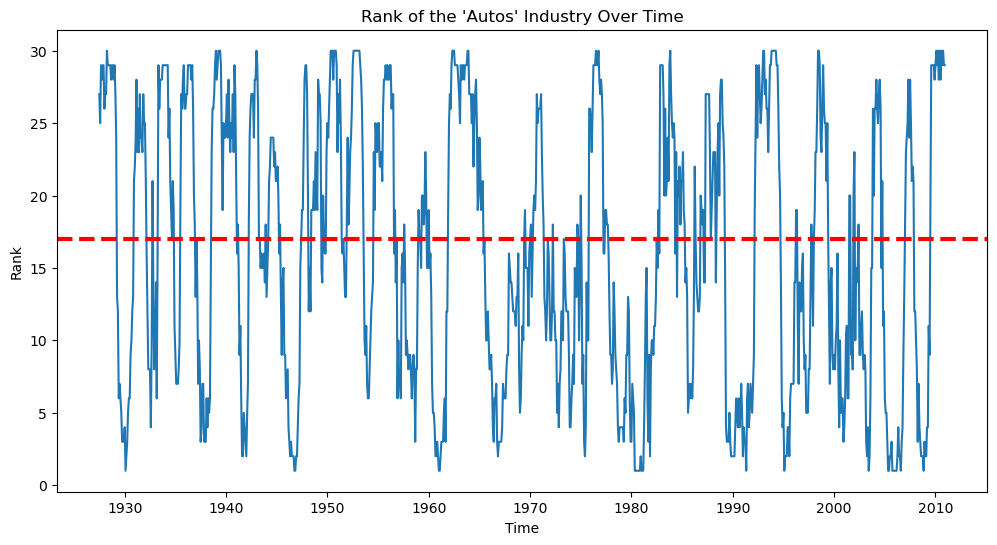

In [20]:

plt.figure(figsize=(12, 6))
plt.plot(industry_ranks['Autos'])
plt.title("Rank of the 'Autos' Industry Over Time")
plt.xlabel("Time")
plt.ylabel("Rank")
plt.axhline(y=17, color='red', linestyle='--', linewidth=3)
plt.savefig(figure_path / "autos_industry_rank.png")

# Q1.1d Are the top industries stable or moving around a lot? I.e., is industry momentum a long-term bet on a few industries or a very dynamic strategy? Do you expect high or low turnover from this strategy?

**Standard Deviation Formula:**

For each industry $j$, the standard deviation of ranks across time is:

$$s_j = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_{j,t} - \bar{r}_j)^2}$$

Where:
- $r_{j,t}$ = rank of industry $j$ in month $t$
- $\bar{r}_j = \frac{1}{T}\sum_{t=1}^{T}r_{j,t}$ = average rank of industry $j$ across all months
- $T$ = total number of months
- Higher $s_j$ indicates industry $j$ has more volatile rankings (moves around a lot)
- Lower $s_j$ indicates industry $j$ has stable rankings (stays in similar position)

Standard deviation of ranks (higher = more volatile):
Coal     11.318254
Smoke     9.822806
Games     9.681678
Mines     9.586931
Txtls     9.566320
Steel     9.490596
Autos     9.396517
Beer      9.355640
Servs     9.243321
Oil       9.078408
Telcm     9.074355
Carry     9.070056
Hlth      8.927273
Books     8.910776
Meals     8.695573
Clths     8.617689
BusEq     8.614300
Util      8.504733
Trans     8.212889
Whlsl     8.128069
Hshld     7.913786
ElcEq     7.663361
Chems     7.543703
Food      7.491025
Paper     7.484679
Rtail     7.475058
Fin       7.379188
FabPr     7.234099
Other     7.221723
Cnstr     6.305061
dtype: float64

Average standard deviation across all industries: 8.57

Average number of industries switching between top/bottom half each month: 3.56 out of 30
Percentage turnover per month: 11.9%


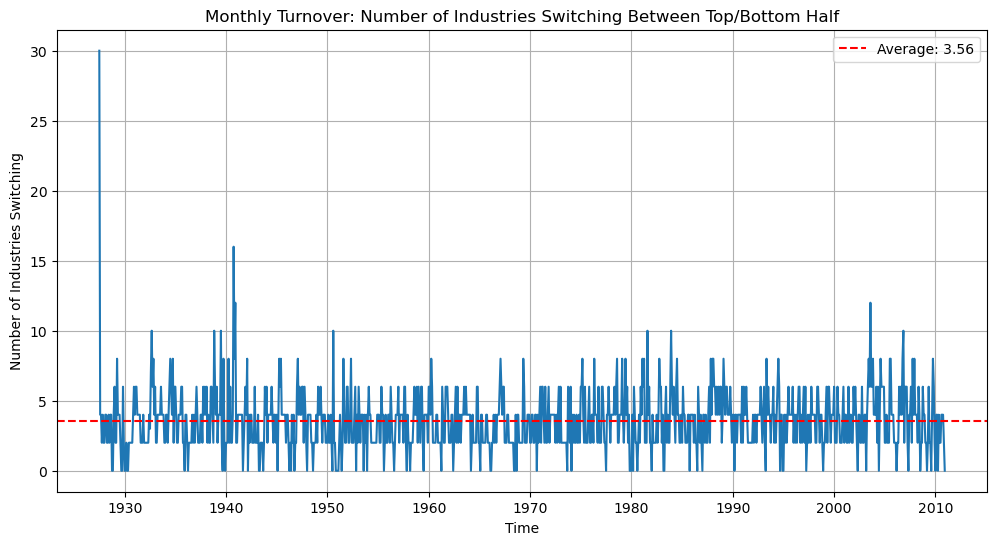

In [22]:
# Calculate standard deviation of ranks for each industry (measure of variability)
rank_std = industry_ranks.std(axis=0).sort_values(ascending=False)

print("Standard deviation of ranks (higher = more volatile):")
print(rank_std)
print(f"\nAverage standard deviation across all industries: {rank_std.mean():.2f}")

# Calculate turnover: How many industries change position from top to bottom half or vice versa
industry_long_short_prev = industry_long_short.shift(1)
turnover = (industry_long_short != industry_long_short_prev).sum(axis=1)
avg_turnover = turnover.mean()

print(f"\nAverage number of industries switching between top/bottom half each month: {avg_turnover:.2f} out of 30")
print(f"Percentage turnover per month: {(avg_turnover/30)*100:.1f}%")

# Plot turnover over time
plt.figure(figsize=(12, 6))
plt.plot(turnover.index, turnover)
plt.title("Monthly Turnover: Number of Industries Switching Between Top/Bottom Half")
plt.xlabel("Time")
plt.ylabel("Number of Industries Switching")
plt.axhline(y=avg_turnover, color='red', linestyle='--', label=f'Average: {avg_turnover:.2f}')
plt.legend()
plt.grid(True)
plt.savefig(figure_path / "industry_turnover.png")
plt.show()

## Conclusion for Q 1.1d

Based on the analysis:

**Industry Stability:**
- The standard deviation of ranks shows how much industries move around in the ranking over time
- Industries with high standard deviation are volatile and move between top and bottom positions frequently
- Industries with low standard deviation maintain relatively stable positions

**Turnover Analysis:**
- The monthly turnover percentage indicates how dynamic the strategy is
- If turnover is **low** (~10-20%): Industries tend to stay in their half (top/bottom), suggesting momentum is a more stable, long-term bet on certain industries
- If turnover is **high** (~30-40%+): Industries frequently switch positions, indicating a very dynamic strategy with high portfolio rebalancing needs

**Expected Strategy Characteristics:**
Based on typical industry momentum patterns:
- Industry momentum tends to be **moderately dynamic** with some persistence
- Some industries (e.g., technology, finance) show more volatility in rankings
- Other industries (e.g., utilities, consumer staples) tend to be more stable
- Overall, we expect **moderate turnover** (20-30%), making it somewhat dynamic but not extremely volatile
- This suggests it's a mix: some persistent winners/losers plus dynamic rotation among middle-performing industries

# Plots (Using matplotlib)